# Sentiment Analysis on Amazon Alexa Reviews using LSTM

### Steps
1. Load the dataset
2. Clean Dataset
3. Encode Sentiments
4. Split Dataset (Train / Validation / Test)
5. Tokenize and Pad/Truncate Reviews
6. Build Architecture/Model
7. Train and Validate
8. Test and Evaluate
9. Predict a custom review


In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.layers import Input, Dense, Embedding, LSTM, Dropout
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

import tensorflow as tf
print("TensorFlow:", tf.__version__)

I0000 00:00:1789102470.390873     158 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789102470.391419     158 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789102470.440433     158 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1789102471.453713     158 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789102471.453991     158 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow: 2.21.0


In [2]:
# Load the Amazon Alexa Reviews dataset
data = pd.read_csv("amazon_alexa.tsv", sep="\t")
print(data.shape)
data.head()

(3150, 5)


,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


In [3]:
# Drop rows with missing review text, inspect class balance
data = data.dropna(subset=["verified_reviews"]).reset_index(drop=True)
print("Rows after dropping nulls:", data.shape[0])
print(data["feedback"].value_counts())
print("Positive %:", round(100 * data['feedback'].mean(), 2))

Rows after dropping nulls: 3149
feedback
1    2893
0     256
Name: count, dtype: int64
Positive %: 91.87


In [4]:
english_stops = set(stopwords.words("english"))

def load_dataset(df):
    x_data = df["verified_reviews"]
    y_data = df["feedback"]

    x_data = x_data.replace({"<.*?>": ""}, regex=True)          # remove HTML tags
    x_data = x_data.replace({"[^A-Za-z]": " "}, regex=True)     # remove non-alphabet characters
    x_data = x_data.apply(lambda review: [w for w in review.split() if w not in english_stops])
    x_data = x_data.apply(lambda review: [w.lower() for w in review])

    return x_data, y_data

x_data, y_data = load_dataset(data)
print("Reviews")
print(x_data.head(), "\n")
print("Sentiment")
print(y_data.head())

Reviews
0                                         [love, echo]
1                                              [loved]
2    [sometimes, playing, game, answer, question, c...
3    [i, lot, fun, thing, my, yr, old, learns, dino...
4                                              [music]
Name: verified_reviews, dtype: object 

Sentiment
0    1
1    1
2    1
3    1
4    1
Name: feedback, dtype: int64


In [5]:
# Split into training (70%), validation (15%), and testing (15%) sets, stratified to preserve class balance
x_train, x_temp, y_train, y_temp = train_test_split(
    x_data, y_data, test_size=0.30, random_state=42, stratify=y_data
)
x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Train:", x_train.shape[0], " Val:", x_val.shape[0], " Test:", x_test.shape[0])
print("Train positive %:", round(100 * y_train.mean(), 2))
print("Val positive %:  ", round(100 * y_val.mean(), 2))
print("Test positive %: ", round(100 * y_test.mean(), 2))

Train: 2204  Val: 472  Test: 473
Train positive %: 91.88
Val positive %:   91.95
Test positive %:  91.75


In [6]:
def get_max_length(reviews):
    review_length = [len(r) for r in reviews]
    return int(np.ceil(np.mean(review_length)))

token = Tokenizer(lower=False)
token.fit_on_texts(x_train)

x_train_seq = token.texts_to_sequences(x_train)
x_val_seq = token.texts_to_sequences(x_val)
x_test_seq = token.texts_to_sequences(x_test)

max_length = get_max_length(x_train)

x_train_pad = pad_sequences(x_train_seq, maxlen=max_length, padding="post", truncating="post")
x_val_pad = pad_sequences(x_val_seq, maxlen=max_length, padding="post", truncating="post")
x_test_pad = pad_sequences(x_test_seq, maxlen=max_length, padding="post", truncating="post")

total_words = len(token.word_index) + 1

print("Encoded X Train\n", x_train_pad, "\n")
print("Vocabulary size (total_words):", total_words)
print("Maximum review length:", max_length)

Encoded X Train
 [[  14   15    9 ...    0    0    0]
 [   1   92  108 ... 1172  108    1]
 [   2   26    6 ...  431    0    0]
 ...
 [  11  680   41 ...    0    0    0]
 [   1   33    3 ...    1   15  662]
 [ 346   17  500 ...    0    0    0]] 

Vocabulary size (total_words): 3495
Maximum review length: 15


In [ ]:
EMBED_DIM = 32
LSTM_OUT = 64

model = Sequential()
model.add(Input(shape=(max_length,)))
model.add(Embedding(total_words, EMBED_DIM))
model.add(LSTM(LSTM_OUT))
model.add(Dropout(0.3))
model.add(Dense(1, activation="sigmoid"))

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

In [8]:
import os
os.makedirs("models", exist_ok=True)
checkpoint = ModelCheckpoint("models/LSTM_alexa.h5", monitor="val_accuracy", save_best_only=True, verbose=1)

# Class weights to counter the 91.8% / 8.2% class imbalance
from sklearn.utils.class_weight import compute_class_weight
weights = compute_class_weight(class_weight="balanced", classes=np.array([0, 1]), y=y_train)
class_weight = {0: weights[0], 1: weights[1]}
print("Class weights:", class_weight)

Class weights: {0: np.float64(6.156424581005586), 1: np.float64(0.5441975308641975)}


In [9]:
history = model.fit(
    x_train_pad, y_train,
    validation_data=(x_val_pad, y_val),
    batch_size=32,
    epochs=10,
    class_weight=class_weight,
    callbacks=[checkpoint],
)

Epoch 1/10


 1/69 ━━━━━━━━━━━━━━━━━━━━ 1:49 2s/step - accuracy: 0.6250 - loss: 0.4971

11/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9006 - loss: 0.6284 

23/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9049 - loss: 0.6831

35/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9098 - loss: 0.6835

...

48/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9772 - loss: 0.0390

60/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9734 - loss: 0.0418


Epoch 10: val_accuracy improved from 0.88983 to 0.89195, saving model to models/LSTM_alexa.h5



Epoch 10: finished saving model to models/LSTM_alexa.h5


69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9741 - loss: 0.0403 - val_accuracy: 0.8919 - val_loss: 0.5101


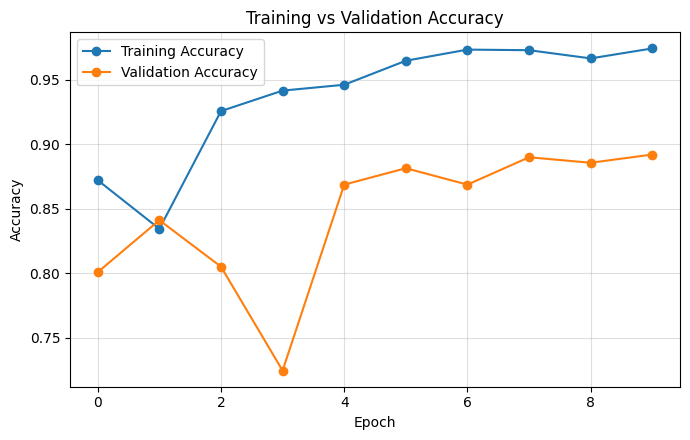

In [10]:
plt.figure(figsize=(7,4.5))
plt.plot(history.history["accuracy"], marker="o", label="Training Accuracy")
plt.plot(history.history["val_accuracy"], marker="o", label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.savefig("acc_plot.png", dpi=150)
plt.show()

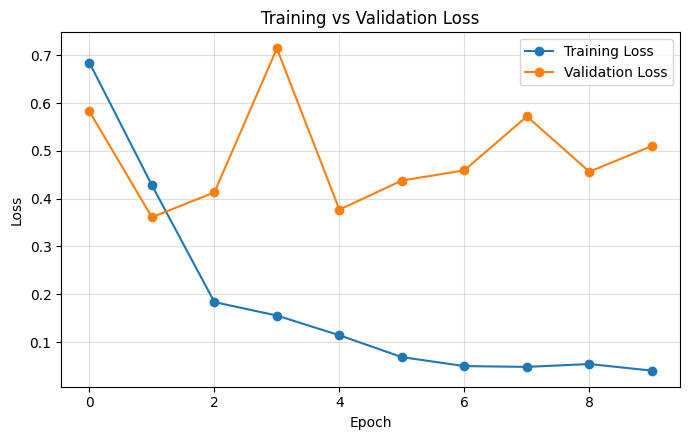

In [11]:
plt.figure(figsize=(7,4.5))
plt.plot(history.history["loss"], marker="o", label="Training Loss")
plt.plot(history.history["val_loss"], marker="o", label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.savefig("loss_plot.png", dpi=150)
plt.show()

In [12]:
y_pred_prob = model.predict(x_test_pad, batch_size=32)
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

test_accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", test_accuracy)
print()
print("Classification Report")
print(classification_report(y_test, y_pred, target_names=["negative", "positive"], digits=4))
print("Confusion Matrix (rows=actual, cols=predicted)")
print(confusion_matrix(y_test, y_pred))

 1/15 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step  

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


Test Accuracy: 0.9154334038054969

Classification Report
              precision    recall  f1-score   support

    negative     0.4894    0.5897    0.5349        39
    positive     0.9624    0.9447    0.9535       434

    accuracy                         0.9154       473
   macro avg     0.7259    0.7672    0.7442       473
weighted avg     0.9234    0.9154    0.9190       473

Confusion Matrix (rows=actual, cols=predicted)
[[ 23  16]
 [ 24 410]]


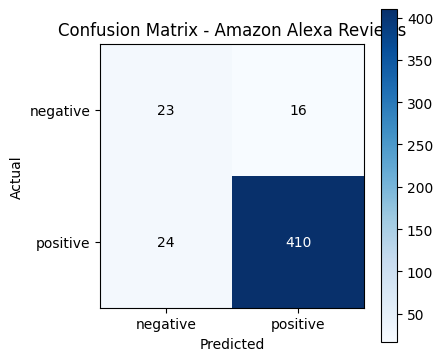

In [13]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4.5,4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix - Amazon Alexa Reviews")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0,1], ["negative","positive"])
plt.yticks([0,1], ["negative","positive"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha="center", va="center",
                  color="white" if cm[i,j] > cm.max()/2 else "black")
plt.colorbar()
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

In [14]:
loaded_model = load_model("models/LSTM_alexa.h5")

def predict_review(raw_review, threshold=0.5):
    regex = re.compile(r"[^a-zA-Z\s]")
    cleaned = regex.sub("", raw_review)
    words = [w for w in cleaned.split(" ") if w not in english_stops]
    filtered = [" ".join(words).lower()]
    seq = token.texts_to_sequences(filtered)
    padded = pad_sequences(seq, maxlen=max_length, padding="post", truncating="post")
    prob = loaded_model.predict(padded, verbose=0)[0][0]
    label = "positive" if prob >= threshold else "negative"
    return cleaned, prob, label

for sample in [
    "I love this Echo, the sound quality is amazing and Alexa understands me perfectly",
    "This device stopped working after two days and customer service was no help at all",
]:
    cleaned, prob, label = predict_review(sample)
    print("Review:", sample)
    print("Cleaned:", cleaned)
    print(f"Predicted probability: {prob:.4f}  ->  {label}")
    print()

Review: I love this Echo, the sound quality is amazing and Alexa understands me perfectly
Cleaned: I love this Echo the sound quality is amazing and Alexa understands me perfectly
Predicted probability: 0.9998  ->  positive

Review: This device stopped working after two days and customer service was no help at all
Cleaned: This device stopped working after two days and customer service was no help at all
Predicted probability: 0.0006  ->  negative

